                 Unnamed: 0 2024-09-30 2024-06-30 2024-03-31 2023-12-31  \
0                       报告期        三季报         中报        一季报         年报   
1                      报表类型       合并报表       合并报表       合并报表       合并报表   
2                      营业收入    7198300    4680100    2130100    9677300   
3                       NaN    2518200    2550000    2130100    2516700   
4                        产品    7198300    4680100    2130100    9677300   
..                      ...        ...        ...        ...        ...   
58                     中国大陆        NaN        NaN        NaN        NaN   
59                       荷兰        NaN        NaN        NaN        NaN   
60                       挪威        NaN        NaN        NaN        NaN   
61                     其他地区        NaN        NaN        NaN        NaN   
62              2014年之前地区分类        NaN        NaN        NaN        NaN   

   2023-09-30 2023-06-30 2023-03-31 2022-12-31 2022-09-30  ... 2017-03-31  \
0         三季报         

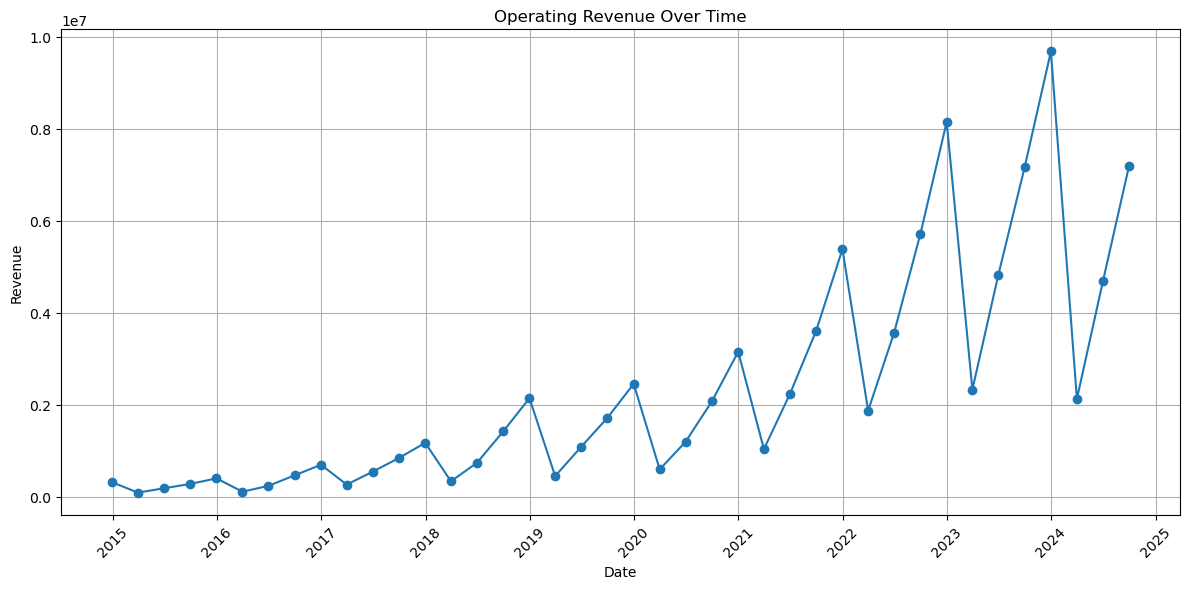

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_excel('file_name.xlsx')
print(df)





# Extract the data of operating income
revenue_data = df.iloc[2, 1:]
print(revenue_data)
print(type(revenue_data))



# Since the column name of the original data is "date", here we extract the date as the X-axis.
dates = pd.to_datetime(revenue_data.index)

# Sort the data according to the date
revenue_data_sorted = revenue_data.iloc[dates.argsort()]
dates_sorted = dates.sort_values()

# Draw a time series chart of operating income
plt.figure(figsize=(12, 6))
plt.plot(dates_sorted, revenue_data_sorted, marker='o')
plt.title('Operating Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2024-09-30    2518200
2024-06-30    2550000
2024-03-31    2130100
2023-12-31    2516700
2023-09-30    2335000
2023-06-30    2492700
2023-03-31    2332900
2022-12-31    2431800
2022-09-30    2145400
2022-06-30    1693400
2022-03-31    1875600
2021-12-31    1771900
2021-09-30    1375700
2021-06-30    1195800
2021-03-31    1038900
2020-12-31    1074400
2020-09-30     877100
2020-06-30     603600
2020-03-31     598500
2019-12-31     738400
2019-09-30     630286
2019-06-30     634968
2019-03-31     454146
2018-12-31     722587
2018-09-30     682442
2018-06-30     400223
2018-03-31     340875
2017-12-31     328825
2017-09-30     298467
2017-06-30     278956
2017-03-31     269627
2016-12-31     228463
2016-09-30     229843
2016-06-30     127002
2016-03-31     114705
2015-12-31     121438
2015-09-30      93679
2015-06-30      95498
2015-03-31      93988
Name: 3, dtype: object
<class 'pandas.core.series.Series'>


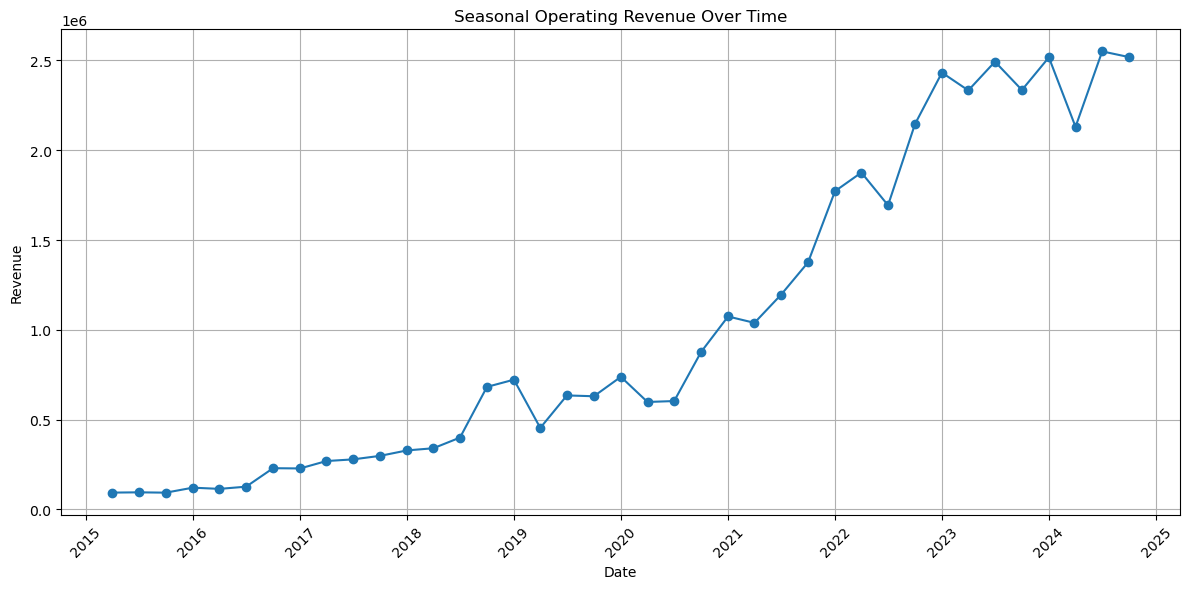

In [2]:
# Extract the data of operating income
revenue_data_new = df.iloc[3, 1:40]
print(revenue_data_new)
print(type(revenue_data_new))

# Convert the unit into actual figures (such as actual dollars)
# revenue_data_actual = revenue_data * 1e6



dates1 = pd.to_datetime(revenue_data_new.index)

revenue_data1_sorted = revenue_data_new.iloc[dates1.argsort()]
dates1_sorted = dates1.sort_values()


plt.figure(figsize=(12, 6))
plt.plot(dates1_sorted, revenue_data1_sorted, marker='o')
plt.title('Seasonal Operating Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2015-03-31      93988
2015-06-30      95498
2015-09-30      93679
2015-12-31     121438
2016-03-31     114705
2016-06-30     127002
2016-09-30     229843
2016-12-31     228463
2017-03-31     269627
2017-06-30     278956
2017-09-30     298467
2017-12-31     328825
2018-03-31     340875
2018-06-30     400223
2018-09-30     682442
2018-12-31     722587
2019-03-31     454146
2019-06-30     634968
2019-09-30     630286
2019-12-31     738400
2020-03-31     598500
2020-06-30     603600
2020-09-30     877100
2020-12-31    1074400
2021-03-31    1038900
2021-06-30    1195800
2021-09-30    1375700
2021-12-31    1771900
2022-03-31    1875600
2022-06-30    1693400
2022-09-30    2145400
2022-12-31    2431800
2023-03-31    2332900
2023-06-30    2492700
2023-09-30    2335000
2023-12-31    2516700
2024-03-31    2130100
2024-06-30    2550000
2024-09-30    2518200
dtype: object
=======================================================================shujuyuan========================================
2015-03

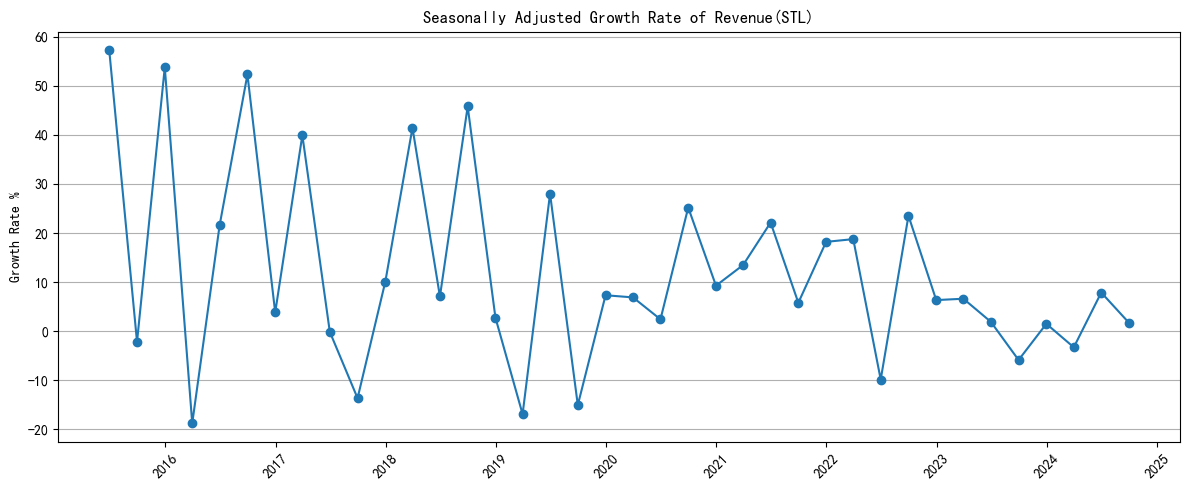

ADF Statistic: -8.580091202690008
p-value: 7.770639182022299e-14
The data is likely stationary (p-value < 0.05).


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False




# Convert the data into time series format
revenue_ts = pd.Series(revenue_data1_sorted.values, index=dates1_sorted)
print(revenue_ts)
#print(revenue_data)

from statsmodels.tsa.seasonal import STL

# Perform seasonal decomposition using STL (Seasonal and Trend decomposition using LOESS)
# We will use a period of 4 (quarterly data) to account for seasonal effects

stl = STL(revenue_ts, period=4)
result = stl.fit()
print('=======================================================================shujuyuan========================================')
print(revenue_ts)
# Get the seasonally adjusted data (detrended data)
detrended_revenue = result.trend + result.resid
B = detrended_revenue
print('==========================B================================================')
print(B)


# Calculate the growth rate for detrended (seasonally adjusted) revenue
A = B.pct_change().dropna() * 100
print('====================================best===========================')
print(A)

# Plot the detrended revenue growth rate
plt.figure(figsize=(12, 5))
plt.plot(A.index, A.values, marker = 'o')


plt.title('Seasonally Adjusted Growth Rate of Revenue(STL)')

plt.ylabel('Growth Rate %')
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from statsmodels.tsa.stattools import adfuller


result = adfuller(A)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("The data is likely stationary (p-value < 0.05).")
else:
    print("The data is likely non-stationary (p-value >= 0.05).")

In [4]:
from statsmodels.tsa.ar_model import AutoReg

# Divide the training set and the test set (the last three quarters are used as the test set)
train = A[:35]
# print(train)
test = A[35:]

# Train the autoregressive model
ar_model = AutoReg(train, lags=8)
model_fitted = ar_model.fit()


print(model_fitted.summary())


# Explore different orders and select the optimal AR model
aic_values = []
bic_values = []
for p in range(1, 9):  
    model = AutoReg(train, lags=p)
    model_fitted = model.fit()
    aic_values.append(model_fitted.aic)
    bic_values.append(model_fitted.bic)

# Find the order numbers corresponding to the minimum values of AIC and BIC
optimal_aic_p = np.argmin(aic_values) + 1
optimal_bic_p = np.argmin(bic_values) + 1

print(f"Optimal AR order based on AIC: {optimal_aic_p}")
print(f"Optimal AR order based on BIC: {optimal_bic_p}")



#ar_params = ar_params = ar_model = AutoReg(trend_component, lags=4).fit()
#ar_params.summary()

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   35
Model:                     AutoReg(8)   Log Likelihood                -103.778
Method:               Conditional MLE   S.D. of innovations             11.299
Date:                Sat, 26 Apr 2025   AIC                            227.555
Time:                        20:34:18   BIC                            240.513
Sample:                    06-30-2017   HQIC                           231.408
                         - 12-31-2023                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.9465      6.714      2.375      0.018       2.787      29.106
y.L1          -0.1685      0.177     -0.953      0.340      -0.515       0.178
y.L2           0.2467      0.183      1.346      0.1

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

===============predictions========================
2024-03-31    14.880429
2024-06-30    15.052318
2024-09-30    15.580524
Freq: QE-DEC, dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


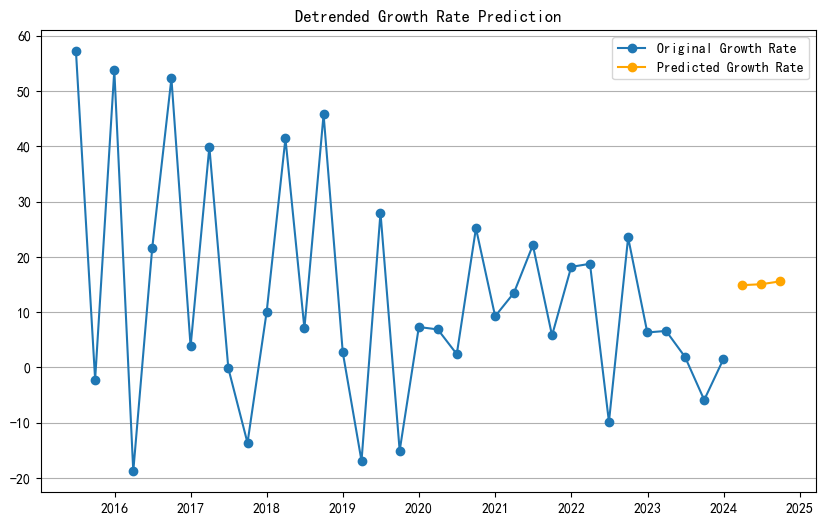

2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
2024-09-30    2.525915e+06
dtype: float64
===================k=======================
2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
dtype: float64
2024-03-31    2.380928e+06
2024-06-30    2.302683e+06
2024-09-30    2.483806e+06
dtype: float64
===================h=====================
2024-03-31    1.148804
2024-06-30    1.150523
2024-09-30    1.155805
Freq: QE-DEC, dtype: float64
=========n============
2024-03-31    2.735220e+06
2024-06-30    2.649290e+06
2024-09-30    2.870796e+06
dtype: float64
<class 'pandas.core.series.Series'>


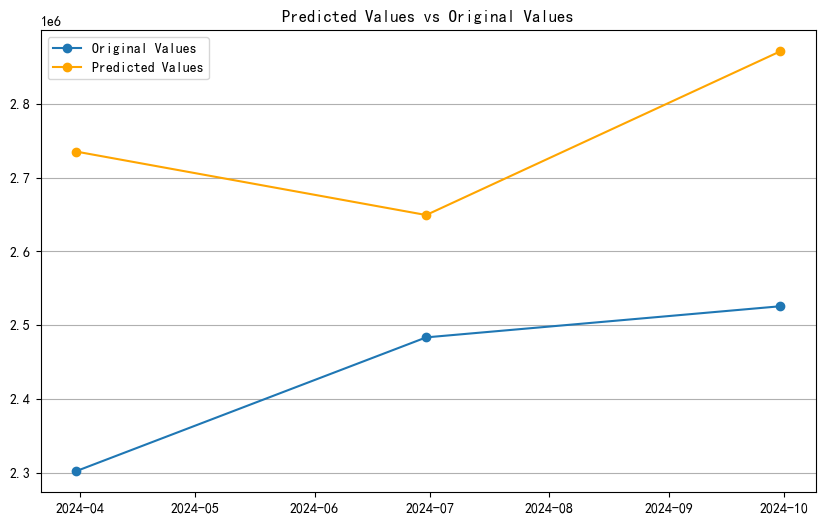

In [5]:
# Make predictions using the model
predictions = model_fitted.predict(start=len(train), end=len(train) + len(test) - 1)


#print(detrended_growth_rate)
print('===============predictions========================')
print(predictions)



plt.figure(figsize=(10, 6))
plt.plot(A.index[:-3], A.values[:-3], marker ='o', label='Original Growth Rate')
plt.plot(A.index[35:], predictions, label='Predicted Growth Rate', marker = 'o', color='orange')
plt.legend()
plt.title('Detrended Growth Rate Prediction')
plt.grid(True, axis='y')  

plt.show()

m = B.iloc[-4 : ]
print(m)
s = m.iloc[1:]
k = m[-5:-1]
print('===================k=======================')
print(k)
k.index = ('2024-03-31', '2024-06-30', '2024-09-30')
print(k)
h = 1 + predictions * 0.01
print('===================h=====================')
print(h)
h.index = ('2024-03-31', '2024-06-30', '2024-09-30')
n = k * h

print('=========n============')
print(n)
print(type(n))
dates = pd.to_datetime(['2024-03-31', '2024-06-30', '2024-09-30'])

plt.figure(figsize=(10, 6))
plt.plot(s.index, s.values, marker ='o', label='Original Values')
plt.plot(dates, n.values, label='Predicted Values', marker = 'o', color='orange')
plt.legend()
plt.title('Predicted Values vs Original Values')
plt.grid(True, axis='y')  

plt.show()

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

actualValue = A[35:]
print(actualValue)
print(predictions)



#  MSE
mse = mean_squared_error(actualValue, predictions)
print(f'Mean Squared Error (MSE): {mse}')

#  RMSE (Root Mean Square Error)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

#  MAE (Average Absolute Error)
mae = mean_absolute_error(actualValue, predictions)
print(f'Mean Absolute Error (MAE): {mae}')

#  R²
r2 = r2_score(actualValue, predictions)
print(f'R² (Coefficient of Determination): {r2}')


2024-03-31   -3.286328
2024-06-30    7.865725
2024-09-30    1.695361
dtype: float64
2024-03-31    14.880429
2024-06-30    15.052318
2024-09-30    15.580524
Freq: QE-DEC, dtype: float64
Mean Squared Error (MSE): 191.49197268936504
Root Mean Squared Error (RMSE): 13.838062461535756
Mean Absolute Error (MAE): 13.079504311475658
R² (Coefficient of Determination): -8.203450228738072


In [7]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd


train = A[:35]
test = A[35:]
#print(train)
#print(test)

# 2.  ARMA 
model = ARIMA(train, order=(1, 0, 4))  # (p, d, q) 这里 d=0 表示 ARMA（非差分）
Armamodel_fitted = model.fit()  # 拟合模型


print(Armamodel_fitted.summary())


p_values = range(1, 6)  
q_values = range(1, 6)  


aic_values = []
bic_values = []

for p in p_values:
    for q in q_values:
        model = ARIMA(train, order=(p, 0, q))  # (p, d, q) 这里 d=0 表示 ARMA
        model_fitted = model.fit()
        aic_values.append(model_fitted.aic)
        bic_values.append(model_fitted.bic)

# Find the combination of the smallest model order for AIC
best_aic_index = np.argmin(aic_values)
best_bic_index = np.argmin(bic_values)

best_p_aic, best_q_aic = divmod(best_aic_index, len(q_values))
best_p_bic, best_q_bic = divmod(best_bic_index, len(q_values))

print(f"Best ARMA model based on AIC: AR({best_p_aic+1}, {best_q_aic+1})")
print(f"Best ARMA model based on BIC: AR({best_p_bic+1}, {best_q_bic+1})")


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   35
Model:                 ARIMA(1, 0, 4)   Log Likelihood                -144.967
Date:                Sat, 26 Apr 2025   AIC                            303.934
Time:                        20:34:19   BIC                            314.821
Sample:                    06-30-2015   HQIC                           307.692
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.9920      3.766      3.450      0.001       5.611      20.373
ar.L1         -0.5368      0.298     -1.799      0.072      -1.122       0.048
ma.L1          0.5440    920.820      0.001      1.0

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to 

Best ARMA model based on AIC: AR(1, 4)
Best ARMA model based on BIC: AR(1, 4)


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2024-03-31     5.319161
2024-06-30    19.561569
2024-09-30    13.107210
Freq: QE-DEC, Name: predicted_mean, dtype: float64


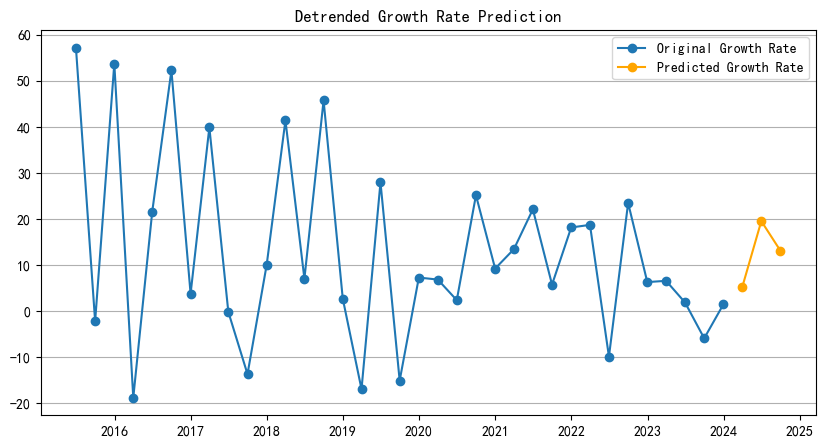

2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
2024-09-30    2.525915e+06
dtype: float64
===================k=======================
2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
dtype: float64
2024-03-31    2.380928e+06
2024-06-30    2.302683e+06
2024-09-30    2.483806e+06
dtype: float64
===================h=====================
2024-03-31    1.053192
2024-06-30    1.195616
2024-09-30    1.131072
Freq: QE-DEC, Name: predicted_mean, dtype: float64
=========n============
2024-03-31    2.507573e+06
2024-06-30    2.753124e+06
2024-09-30    2.809363e+06
dtype: float64
<class 'pandas.core.series.Series'>


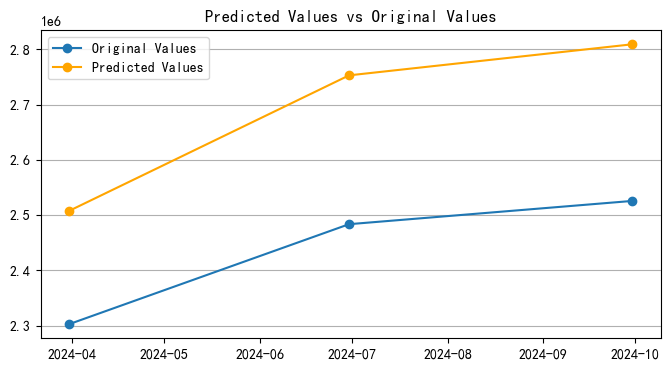

In [8]:
# Make predictions using the model
Armapredictions = Armamodel_fitted.predict(start=len(train), end=len(train) + len(test) - 1)
print(Armapredictions)
#print(detrended_growth_rate)
# print(A)



plt.figure(figsize=(10, 5))
plt.plot(A.index[ :-3], A.values[ :-3], marker ='o', label='Original Growth Rate')
plt.plot(A.index[35:], Armapredictions, label='Predicted Growth Rate', marker = 'o', color='orange')
plt.legend()
plt.title('Detrended Growth Rate Prediction')
plt.grid(True, axis='y')  
plt.show()


m = detrended_revenue.iloc[-4 : ]
print(m)
s = m.iloc[1:]
k = m[-5:-1]
print('===================k=======================')
print(k)
k.index = ('2024-03-31', '2024-06-30', '2024-09-30')
print(k)
h = 1 + Armapredictions * 0.01
print('===================h=====================')
print(h)
h.index = ('2024-03-31', '2024-06-30', '2024-09-30')
n = k * h

print('=========n============')
print(n)
print(type(n))
dates = pd.to_datetime(['2024-03-31', '2024-06-30', '2024-09-30'])

plt.figure(figsize=(8, 4))
plt.plot(s.index, s.values, marker ='o', label='Original Values')
plt.plot(dates, n.values, label='Predicted Values', marker = 'o', color='orange')
plt.legend()
plt.title('Predicted Values vs Original Values')
plt.grid(True, axis='y')  

plt.show()

In [9]:
armaActualValue = A[35:]
print(armaActualValue)




mse = mean_squared_error(armaActualValue, Armapredictions)
print(f'Mean Squared Error (MSE): {mse}')


rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')


mae = mean_absolute_error(armaActualValue, Armapredictions)
print(f'Mean Absolute Error (MAE): {mae}')


r2 = r2_score(armaActualValue, Armapredictions)
print(f'R² (Coefficient of Determination): {r2}')

2024-03-31   -3.286328
2024-06-30    7.865725
2024-09-30    1.695361
dtype: float64
Mean Squared Error (MSE): 113.69249808647305
Root Mean Squared Error (RMSE): 10.662668431798537
Mean Absolute Error (MAE): 10.571060454645453
R² (Coefficient of Determination): -4.464266897585026


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pmdarima import auto_arima
#print(detrended_growth_rate)
arimaTrain = A[:35]  
arimaTest = A[35:]   

#  auto_arima 
model_auto = auto_arima(arimaTrain, seasonal=False, stepwise=True, trace=True)
model_auto.summary()


arimaModel = ARIMA(arimaTrain, order=(1, 0, 0))  # (p, d, q) 
arimaModel_fitted = arimaModel.fit()  
print(arimaModel_fitted.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=317.442, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=323.076, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=324.988, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=325.029, Time=0.00 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=315.443, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=318.285, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=320.509, Time=0.00 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=315.676, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=316.778, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=314.639, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=312.853, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=311.837, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=312.924, Time

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


2024-03-31    16.514462
2024-06-30    11.254238
2024-09-30    13.096863
Freq: QE-DEC, Name: predicted_mean, dtype: float64


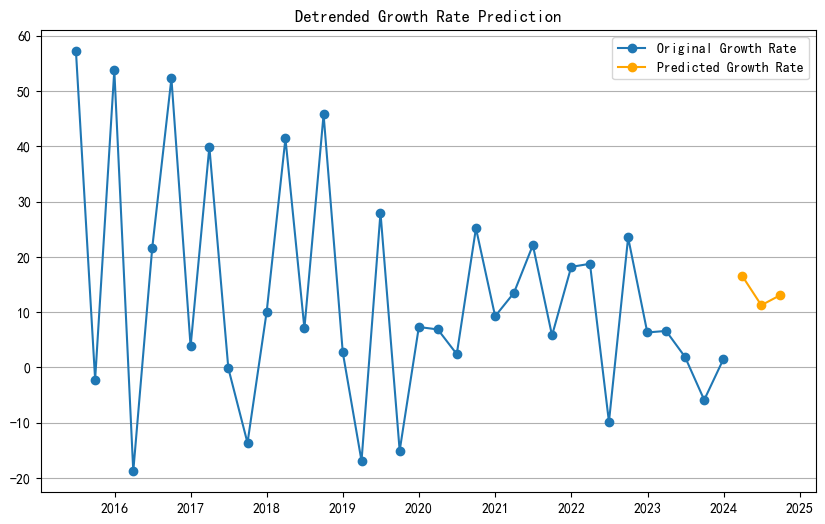

2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
2024-09-30    2.525915e+06
dtype: float64
===================k=======================
2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
dtype: float64
2024-03-31    2.380928e+06
2024-06-30    2.302683e+06
2024-09-30    2.483806e+06
dtype: float64
===================h=====================
2024-03-31    1.165145
2024-06-30    1.112542
2024-09-30    1.130969
Freq: QE-DEC, Name: predicted_mean, dtype: float64
=========n============
2024-03-31    2.774125e+06
2024-06-30    2.561832e+06
2024-09-30    2.809106e+06
dtype: float64
<class 'pandas.core.series.Series'>


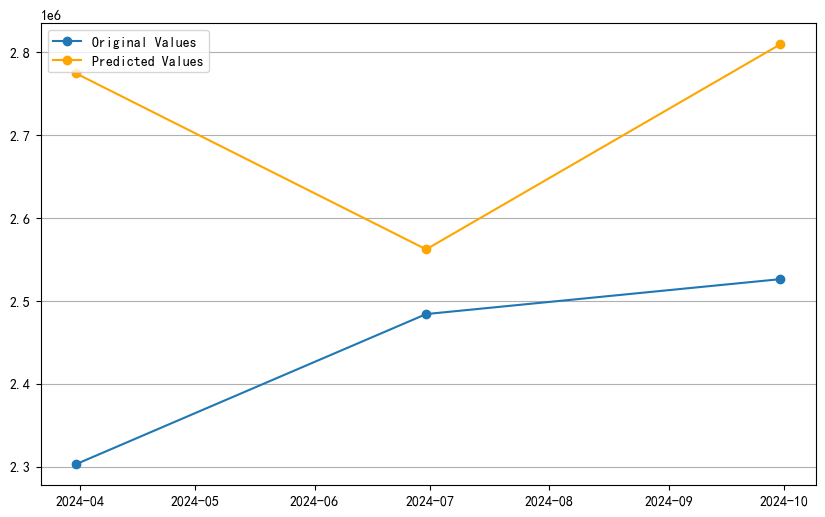

In [11]:
# Make predictions using the model
arimaPredictions = arimaModel_fitted.predict(start=len(train), end=len(train) + len(test) - 1)
print(arimaPredictions)



plt.figure(figsize=(10, 6))
plt.plot(A.index[:-3], A.values[:-3], marker ='o', label='Original Growth Rate')
plt.plot(A.index[35:], arimaPredictions, label='Predicted Growth Rate', marker = 'o', color='orange')
plt.legend()
plt.title('Detrended Growth Rate Prediction')
plt.grid(True, axis='y')  
plt.show()


m = detrended_revenue.iloc[-4 : ]
print(m)
s = m.iloc[1:]
k = m[-5:-1]
print('===================k=======================')
print(k)
k.index = ('2024-03-31', '2024-06-30', '2024-09-30')
print(k)
h = 1 + arimaPredictions * 0.01
print('===================h=====================')
print(h)
h.index = ('2024-03-31', '2024-06-30', '2024-09-30')
n = k * h

print('=========n============')
print(n)
print(type(n))
dates = pd.to_datetime(['2024-03-31', '2024-06-30', '2024-09-30'])

plt.figure(figsize=(10, 6))
plt.plot(s.index, s.values, marker ='o', label='Original Values')
plt.plot(dates, n.values, label='Predicted Values', marker = 'o', color='orange')
plt.legend()
#plt.title('Detrended Growth Rate Prediction')
plt.grid(True, axis='y')  

plt.show()

In [12]:
arimaActualValue = A[35:]
print(arimaActualValue)




mse = mean_squared_error(arimaActualValue, arimaPredictions)
print(f'Mean Squared Error (MSE): {mse}')


rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')


mae = mean_absolute_error(arimaActualValue, arimaPredictions)
print(f'Mean Absolute Error (MAE): {mae}')



r2 = r2_score(arimaActualValue, arimaPredictions)
print(f'R² (Coefficient of Determination): {r2}')

2024-03-31   -3.286328
2024-06-30    7.865725
2024-09-30    1.695361
dtype: float64
Mean Squared Error (MSE): 177.84917510247354
Root Mean Squared Error (RMSE): 13.336010464245803
Mean Absolute Error (MAE): 11.530268043286611
R² (Coefficient of Determination): -7.547752724512209


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=312.924, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=308.814, Time=0.03 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=323.076, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=310.931, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[4] intercept   : AIC=309.764, Time=0.05 sec
 ARIMA(1,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[4] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(1,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(1,0,0)[4] intercept   : AIC=307.657, Time=0.02 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=308.513, Time=0.08 sec
 ARIMA(0,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,1)[4] intercept   : AIC=inf, Time=0.03 sec
 ARIMA(0,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,0,1)(

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   35
Model:                 ARIMA(5, 0, 5)   Log Likelihood                -142.888
Date:                Sat, 26 Apr 2025   AIC                            309.776
Time:                        20:34:23   BIC                            328.440
Sample:                    06-30-2015   HQIC                           316.219
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.1410      3.741      3.513      0.000       5.809      20.473
ar.L1         -0.2606      0.616     -0.423      0.672      -1.467       0.946
ar.L2         -0.3784      0.444     -0.853      0.3

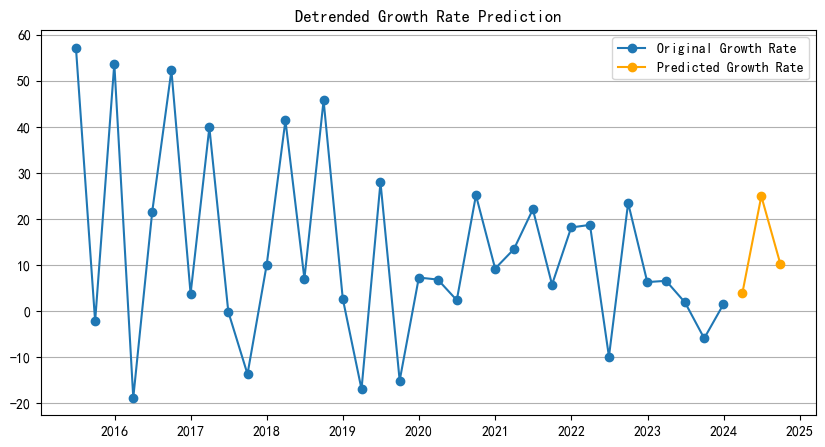

2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
2024-09-30    2.525915e+06
dtype: float64
===================k=======================
2023-12-31    2.380928e+06
2024-03-31    2.302683e+06
2024-06-30    2.483806e+06
dtype: float64
2024-03-31    2.380928e+06
2024-06-30    2.302683e+06
2024-09-30    2.483806e+06
dtype: float64
===================h=====================
2024-03-31    1.039266
2024-06-30    1.249790
2024-09-30    1.101580
Freq: QE-DEC, Name: predicted_mean, dtype: float64
=========n============
2024-03-31    2.474419e+06
2024-06-30    2.877869e+06
2024-09-30    2.736110e+06
dtype: float64
<class 'pandas.core.series.Series'>


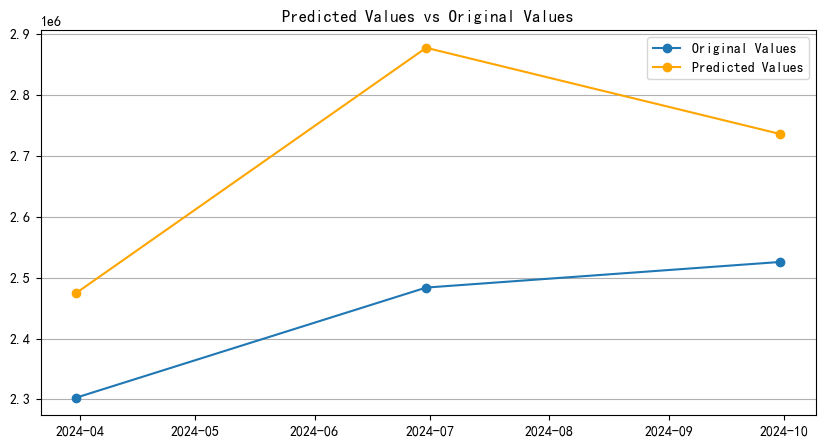

In [13]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = A[:35]
test = A[35:]
# print('==============================train===============================')
# print(train)

#  auto_arima 
sarimaModel_auto = pm.auto_arima(train, seasonal=True, m=4, stepwise=True, trace=True)


#print(sarimaModel_auto.summary())

#  SARIMA prediction

sarimaxModel = SARIMAX(train, order=(0, 0, 0), seasonal_order=(1, 0, 0, 4))
sarimaxModel_fitted = model.fit()  

print(sarimaxModel_fitted.summary())

# Make predictions using the model
sarimaxPredictions = sarimaxModel_fitted.predict(start=len(train), end=len(train) + len(test) - 1)
#print(detrended_growth_rate)

plt.figure(figsize=(10, 5))
plt.plot(A.index[:-3], A.values[:-3], marker ='o', label='Original Growth Rate')
plt.plot(A.index[35:], sarimaxPredictions, label='Predicted Growth Rate', marker = 'o', color='orange')
plt.legend()
plt.title('Detrended Growth Rate Prediction')
plt.grid(True, axis='y')  
plt.show()


m = detrended_revenue.iloc[-4 : ]
print(m)
s = m.iloc[1:]
k = m[-5:-1]
print('===================k=======================')
print(k)
k.index = ('2024-03-31', '2024-06-30', '2024-09-30')
print(k)
h = 1 + sarimaxPredictions * 0.01
print('===================h=====================')
print(h)
h.index = ('2024-03-31', '2024-06-30', '2024-09-30')
n = k * h

print('=========n============')
print(n)
print(type(n))
dates = pd.to_datetime(['2024-03-31', '2024-06-30', '2024-09-30'])

plt.figure(figsize=(10, 5))
plt.plot(s.index, s.values, marker ='o', label='Original Values')
plt.plot(dates, n.values, label='Predicted Values', marker = 'o', color='orange')
plt.legend()
plt.title('Predicted Values vs Original Values')
plt.grid(True, axis='y')  

plt.show()

In [14]:
sarimaxActualValue = A[35:]
# print(sarimaxActualValue)




mse = mean_squared_error(sarimaxActualValue, sarimaxPredictions)
print(f'Mean Squared Error (MSE): {mse}')


rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')


mae = mean_absolute_error(sarimaxActualValue, sarimaxPredictions)
print(f'Mean Absolute Error (MAE): {mae}')



r2 = r2_score(sarimaxActualValue, sarimaxPredictions)
print(f'R² (Coefficient of Determination): {r2}')


Mean Squared Error (MSE): 138.83520386520217
Root Mean Squared Error (RMSE): 11.78283513697795
Mean Absolute Error (MAE): 10.929607961957933
R² (Coefficient of Determination): -5.672670769562005


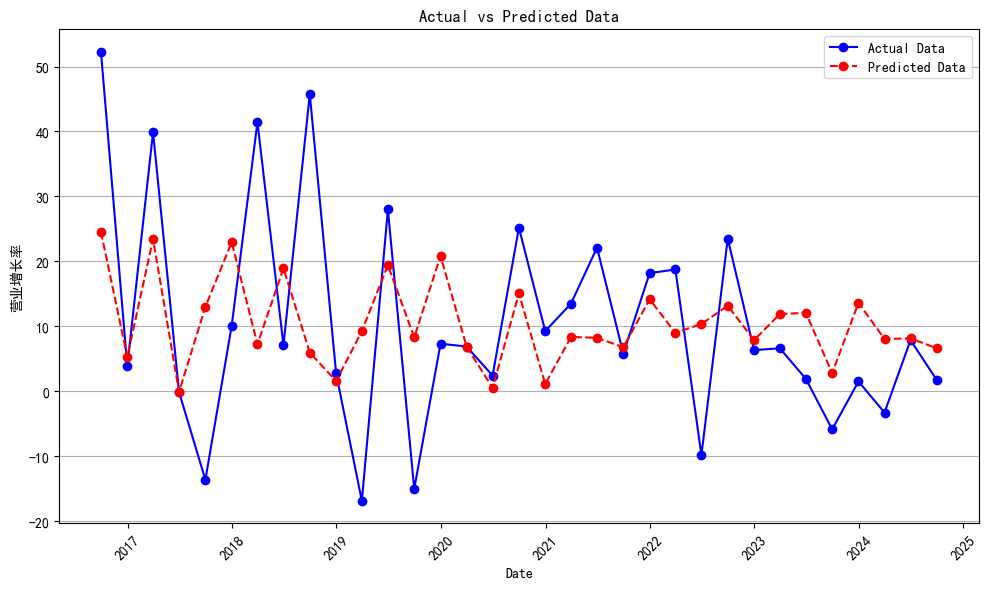

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np
# print(A)
# print(train)
# Create lagged features for the time series data
lag = 5  

# time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')
# print(time)

# Prepare the feature (X) and target (y) for the regression model
X =A.shift(lag).dropna()  # Lagged values as features
# X = time
y = A.dropna()[lag:]  # Current values as target


# Reshape data for linear regression
X = X.values.reshape(-1, 1)
y = y.values

# Train a linear regression model
mutiModel = LinearRegression()
mutiModel.fit(X, y)

# Coefficients and intercept of the fitted model
coefficients = mutiModel.coef_
intercept = mutiModel.intercept_

# Predict using the fitted model
y_pred = mutiModel.predict(X)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker = 'o', color='blue')
# plt.plot(A.index[35:], y_pred, label='Predicted Data', marker = 'o', color='red', linestyle='dashed')
plt.plot(A.index[lag:], y_pred, label='Predicted Data', marker = 'o', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Data')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

# Output the coefficients and intercept
# coefficients, intercept



In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np
# print(A)
# print(train)
# Create lagged features for the time series data
lag = 5  

# time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')
# print(time)

# Prepare the feature (X) and target (y) for the regression model
X =train.shift(lag).dropna()  # Lagged values as features
# X = time
y = train.dropna()[lag:]  # Current values as target


# Reshape data for linear regression
X = X.values.reshape(-1, 1)
y = y.values

# Train a linear regression model
mutiModel = LinearRegression()
mutiModel.fit(X, y)

# Coefficients and intercept of the fitted model
coefficients = mutiModel.coef_
intercept = mutiModel.intercept_

# Predict using the fitted model
testNew = np.array(test).reshape(1, -1)  # 保证是(1,1)二维

y_pred = mutiModel.predict(testNew)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker = 'o', color='blue')
future_time = A.index[-1] + pd.DateOffset(months=3)  
plt.plot(A.index[lag:], y, label='Actual Data', marker = 'o', color='blue')
plt.scatter(future_time, y_pred, label='Predicted Future', color='red', marker='x', s=100)


plt.title('Actual vs Predicted Data')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

# Output the coefficients and intercept
# coefficients, intercept


ValueError: X has 3 features, but LinearRegression is expecting 1 features as input.

In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Create lagged features for the time series data
lag = 5

time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')
# print(time)
X_cost = pd.Series(df.iloc[18,1:40])
m = X_cost.sort_index()
m = pd.Series(m.values, index=dates1_sorted)
# print(m)
# Prepare the feature (X) and target (y) for the regression model
X_pri =A.shift(lag).dropna()  # Lagged values as features
# print(X_pri)
X = pd.concat([X_pri, m.shift(1).dropna()], axis=1).dropna() 
# X = time
print(X)
y = A.dropna()[lag:]  # Current values as target


# Reshape data for linear regression
X = X.values
y = y.values

# Train a linear regression model
mutiModel = LinearRegression()
mutiModel.fit(X, y)

# Coefficients and intercept of the fitted model
coefficients = mutiModel.coef_
intercept = mutiModel.intercept_

# Predict using the fitted model
y_pred = mutiModel.predict(X)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker = 'o', color='blue')
plt.plot(A.index[lag:], y_pred, label='Predicted Data', marker = 'o', color='red', linestyle='dashed')

plt.title('Actual vs Predicted Data')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

Output the coefficients and intercept
coefficients, intercept


X_pri_range = np.linspace(X_pri.min(), X_pri.max(), 20)
X_cost_range = np.linspace(X_cost.min(), X_cost.max(), 20)
X_pri_grid, X_cost_grid = np.meshgrid(X_pri_range, X_cost_range)
X_grid = np.column_stack((X_pri_grid.ravel(), X_cost_grid.ravel()))
y_grid = mutiModel.predict(X_grid).reshape(X_pri_grid.shape)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Actual Data')


ax.plot_surface(X_pri_grid, X_cost_grid, y_grid, alpha=0.5, edgecolor='none')


ax.set_xlabel('Area')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price (10k RMB)')
ax.set_title('Multivariate Linear Regression Plane (Area + Bedrooms)')

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (549018452.py, line 50)

                    0        1        2      3
2016-09-30  57.169559    52724   188982  21.81
2016-12-31  -2.178180   116398   355152  24.68
2017-03-31  53.734356   159926   540088  22.85
2017-06-30 -18.770182    66795   202832  24.77
2017-09-30  21.635802   133456   415127  24.33
2017-12-31  52.266891   178370   668680  21.06
2018-03-31   3.810655   222249   953626   18.9
2018-06-30  39.896916    45653   295223  13.39
2018-09-30  -0.135816   107546   633553  14.51
2018-12-31 -13.642206   259912  1163627  18.26
2019-03-31  10.078138   404202  1741925  18.83
2019-06-30  41.411933    56574   397572  12.46
2019-09-30   7.066590   148679   940435  13.65
2019-12-31  45.749844   267800  1451600  15.58
2020-03-31   2.745303   406900  2050900  16.56
2020-06-30 -16.905610   123400   475100  20.62
2020-09-30  27.982280   250100   952000  20.81
2020-12-31 -15.047164   456400  1622800  21.95
2021-03-31   7.315061   663000  2490600  21.02
2021-06-30   6.876262   221500   817400  21.32
2021-09-30   

C:\Users\19579\AppData\Local\Temp\ipykernel_12916\2858360440.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')


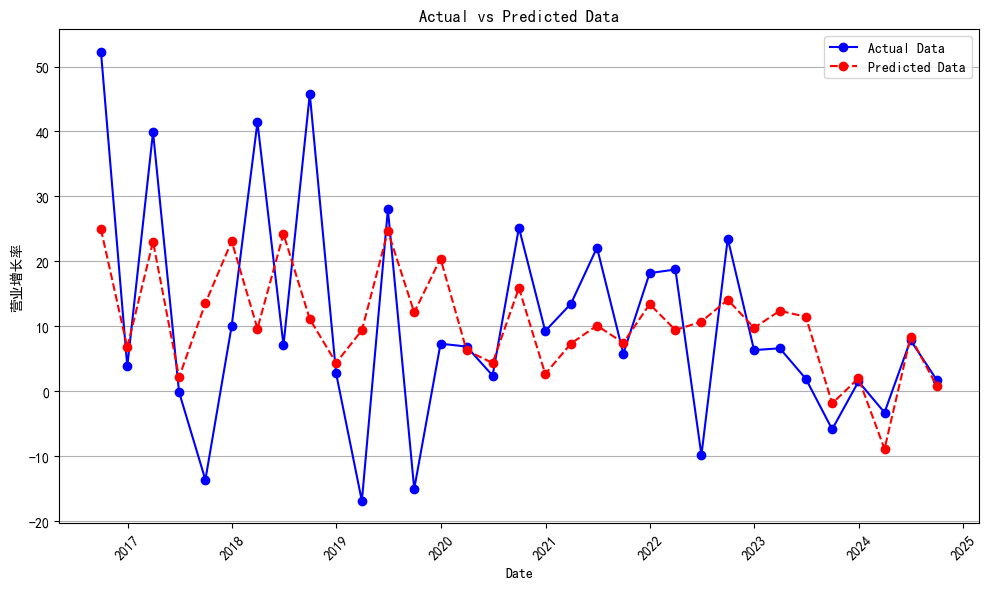

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Create lagged features for the time series data
lag = 5

time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')
# print(time)
X_cost = pd.Series(df.iloc[33,1:40])
m = X_cost.sort_index()
m = pd.Series(m.values, index=dates1_sorted)

X_profit = pd.Series(df.iloc[18,1:40])
n = X_profit.sort_index()
n = pd.Series(n.values, index=dates1_sorted)

X_levelp = pd.Series(df.iloc[48,1:40])
k = X_levelp.sort_index()
k = pd.Series(k.values, index=dates1_sorted)
# Prepare the feature (X) and target (y) for the regression model
X_pri =A.shift(lag).dropna()  # Lagged values as features
# print(X_pri)
X = pd.concat([X_pri, m.shift(1).dropna(), n.shift(1).dropna(), k.shift(1).dropna()], axis=1).dropna() 
# X = time
print(X)
y = A.dropna()[lag:]  # Current values as target


# Reshape data for linear regression
X = X.values
y = y.values

# Train a linear regression model
mutiModel = LinearRegression()
mutiModel.fit(X, y)

# Coefficients and intercept of the fitted model
coefficients = mutiModel.coef_
intercept = mutiModel.intercept_

# Predict using the fitted model
y_pred = mutiModel.predict(X)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker = 'o', color='blue')
plt.plot(A.index[lag:], y_pred, label='Predicted Data', marker = 'o', color='red', linestyle='dashed')

plt.title('Actual vs Predicted Data')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

# Output the coefficients and intercept
# coefficients, intercept

In [ ]:
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


lag = 5

time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')


X_cost = pd.Series(df.iloc[33, 1:40])
m = X_cost.sort_index()
m = pd.Series(m.values, index=dates1_sorted)

X_profit = pd.Series(df.iloc[18, 1:40])
n = X_profit.sort_index()
n = pd.Series(n.values, index=dates1_sorted)

X_levelp = pd.Series(df.iloc[48, 1:40])
k = X_levelp.sort_index()
k = pd.Series(k.values, index=dates1_sorted)


X_pri = A.shift(lag).dropna()


X = pd.concat([X_pri, m.shift(1).dropna(), n.shift(1).dropna(), k.shift(1).dropna()], axis=1).dropna()
print(X)


y = A.dropna()[lag:]
y = y.loc[X.index]  


X = X.values
y = y.values

# Lasso regression
lassoModel = Lasso(alpha=0.5)  
lassoModel.fit(X, y)


coefficients = lassoModel.coef_
intercept = lassoModel.intercept_


y_pred = lassoModel.predict(X)


plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker='o', color='blue')
plt.plot(A.index[lag:], y_pred, label='Predicted Data (Lasso)', marker='o', color='red', linestyle='dashed')

plt.title('Actual vs Predicted Data (Lasso Regression)')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


feature_names = ['Lagged Growth Rate', 'Cost', 'Profit', 'Debt Ratio']

print("\nLasso回归的特征系数：")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

print(f"\n截距 (Intercept): {intercept:.4f}")
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lassoModel, X, y, cv=5, scoring='r2')
print('交叉验证平均R2:', np.mean(scores))

residuals = y - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lassoModel, X, y, cv=5, scoring='r2')
print('交叉验证平均R2:', np.mean(scores))


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 21)}
knn_cv = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)
knn_cv.fit(X, y)

print("最佳K值:", knn_cv.best_params_)


lag = 5

time = pd.date_range(start='2016-9-30', end='2024-9-30', freq='Q')


X_cost = pd.Series(df.iloc[33, 1:40])
m = X_cost.sort_index()
m = pd.Series(m.values, index=dates1_sorted)

X_profit = pd.Series(df.iloc[18, 1:40])
n = X_profit.sort_index()
n = pd.Series(n.values, index=dates1_sorted)

X_levelp = pd.Series(df.iloc[48, 1:40])
k = X_levelp.sort_index()
k = pd.Series(k.values, index=dates1_sorted)


X_pri = A.shift(lag).dropna()


X = pd.concat([X_pri, m.shift(1).dropna(), n.shift(1).dropna(), k.shift(1).dropna()], axis=1).dropna()


y = A.dropna()[lag:]
y = y.loc[X.index] 


X = X.values
y = y.values

# KNN
knnModel = KNeighborsRegressor(n_neighbors=3)  
knnModel.fit(X, y)


y_pred = knnModel.predict(X)


plt.figure(figsize=(10, 6))
plt.plot(A.index[lag:], y, label='Actual Data', marker='o', color='blue')
plt.plot(A.index[lag:], y_pred, label='Predicted Data (KNN)', marker='o', color='red', linestyle='dashed')

plt.title('Actual vs Predicted Data (KNN Regression)')
plt.xlabel('Date')
plt.ylabel('营业增长率')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


rf = RandomForestRegressor()


param_grid_rf = {
    'n_estimators': [50, 100, 200],  # 树的数量
    'max_depth': [5, 10, 20, None],  # 树的最大深度
    'min_samples_split': [2, 5, 10],  # 分裂内部节点所需的最小样本数
    'min_samples_leaf': [1, 2, 4]  # 叶节点的最小样本数
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=10, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


best_rf = grid_search_rf.best_estimator_


y_pred = best_rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
from sklearn.model_selection import cross_val_score


scores = cross_val_score(lasso_cv, X, Y, cv=10, scoring='r2')
print(f"Average R^2 score from cross-validation: {scores.mean()}")


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV


gbdt = GradientBoostingRegressor()


param_grid_gbdt = {
    'n_estimators': [50, 100, 200],  
    'learning_rate': [0.01, 0.1, 0.2],  
    'max_depth': [3, 5, 10],  
    'subsample': [0.8, 1.0]  
}


grid_search_gbdt = GridSearchCV(gbdt, param_grid_gbdt, cv=10)
grid_search_gbdt.fit(X_train, y_train)


print(f"Best parameters for GBDT: {grid_search_gbdt.best_params_}")
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


best_gbdt = grid_search_gbdt.best_estimator_


y_pred = best_gbdt.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
from sklearn.model_selection import cross_val_score


scores = cross_val_score(lasso_cv, X, Y, cv=10, scoring='r2')
print(f"Average R^2 score from cross-validation: {scores.mean()}")
